# Gas Well Flow Forecasting using Deep Learning (CNN + Transformer)

This notebook implements an end-to-end industrial time-series forecasting pipeline to predict future gas flow (`DG`) 6 hours in advance using a CNN + Transformer architecture.

### Objectives:
- Predict `DG(t + 6)` (360 minutes ahead).
- Use a history window of 360 minutes from all sensors.


## 1. Import Required Libraries
Import data processing, visualization, database connection, and deep learning libraries.


In [1]:
import os
from datetime import datetime
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

# Database libraries
from sqlalchemy import create_engine, inspect

# Machine learning libraries
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported")
print(f"TensorFlow version: {tf.__version__}")


✅ Libraries imported
TensorFlow version: 2.21.0


## 2. Database Connection
Establish a connection to the PostgreSQL database containing sensor readings.


In [2]:
# Database connection (using SQLAlchemy)
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'data_esi_sba_2023'
DB_USER = 'postgres'
DB_PASSWORD = 'root'

try:
    engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
    inspector = inspect(engine)
    print("✅ Connected to database")
except Exception as e:
    print(f"❌ Database connection error: {e}")


✅ Connected to database


## 3. Database Schema Inspection
Verify that the required sensor tables are available in the schema.


In [3]:
# Inspect database schema
try:
    table_names = inspector.get_table_names()
    print("Available tables:", table_names)
except Exception as e:
    print(f"❌ Error fetching table names: {e}")
    table_names = []

Available tables: ['cm_values', 'dg_values', 'dp_values', 'of_values', 'op_values', 'pa1_values', 'pa2_values', 'pl_values', 'tt_values', 'pt_values']


In [4]:
# Specify tables and wells of interest
TABLES = ['dg_values', 'cm_values', 'pt_values', 'pl_values', 'dp_values', 'of_values']
WELLS = ["LNB627-CE"]
#LNB712-CE
# Check that each expected table exists and display its columns
for table in TABLES:
    if table not in table_names:
        print(f"⚠️ Table '{table}' not found in database.")
        continue
    cols = inspector.get_columns(table)
    col_names = [col['name'] for col in cols]
    print(f"Table '{table}' columns: {col_names}")


Table 'dg_values' columns: ['time', 'well', 'debitgaz']
Table 'cm_values' columns: ['time', 'well', 'cumulpartiel']
Table 'pt_values' columns: ['time', 'well', 'ptete']
Table 'pl_values' columns: ['time', 'well', 'pligne']
Table 'dp_values' columns: ['time', 'well', 'pdelta']
Table 'of_values' columns: ['time', 'well', 'openfield']


## 4. Load Sensor Data
Load raw sensor readings for the specified well from PostgreSQL tables.
- DG: Gas flow rate
- CM: Cumulative gas production
- PT: Wellhead pressure
- PL: Line pressure
- DP: Differential pressure
- OF: Valve opening factor


In [5]:
# LOAD SENSOR DATA FROM DATABASE TABLES
all_data = []

try:
    # Loop through all requested sensor tables
    for table in TABLES:
        if table not in table_names:
            continue
        print(f"\nLoading '{table}'...")

        # Get table columns metadata
        cols = inspector.get_columns(table)
        col_names = [col['name'] for col in cols]

        # Identify sensor value column (excluding time and well)
        value_cols = [c for c in col_names if c not in ['time', 'well']]

        if len(value_cols) != 1:
            print(f"⚠️ Expected 1 value column in '{table}', found {value_cols}. Skipping table.")
            continue

        value_col = value_cols[0]

        # SQL Query to load well data ordered by time
        query = f"""
            SELECT time, well, {value_col}
            FROM {table}
            WHERE well IN ({', '.join([f"'{w}'" for w in WELLS])})
            ORDER BY time
        """

        try:
            df = pd.read_sql(query, engine)
        except Exception as e:
            print(f"❌ Query error on '{table}': {e}")
            continue

        if df.empty:
            print(f"⚠️ No data returned for '{table}'.")
            continue

        # Standardize dataframe structure
        df = df.rename(columns={value_col: 'value'})
        df['sensor'] = table.split('_')[0].upper()
        df['time'] = pd.to_datetime(df['time'])

        all_data.append(df)
        print(f"✅ Loaded {len(df)} records from '{table}'")

finally:
    try:
        engine.dispose()
        print("\n🔒 Database connection closed successfully")
    except Exception as e:
        print(f"⚠️ Error while closing connection: {e}")



Loading 'dg_values'...
✅ Loaded 371306 records from 'dg_values'

Loading 'cm_values'...
✅ Loaded 257864 records from 'cm_values'

Loading 'pt_values'...
✅ Loaded 38897 records from 'pt_values'

Loading 'pl_values'...
✅ Loaded 41048 records from 'pl_values'

Loading 'dp_values'...
✅ Loaded 40940 records from 'dp_values'

Loading 'of_values'...
✅ Loaded 257920 records from 'of_values'

🔒 Database connection closed successfully


## 5. Merge and Clean Raw Data
Combine all sensor dataframes into a unified time series, remove exact duplicates, and check parameters.


In [6]:
# Combine and clean raw data
if not all_data:
    raise ValueError("No data was loaded from the database. Check TABLES and WELLS.")
df_raw = pd.concat(all_data, ignore_index=True)
df_raw = df_raw.sort_values(['well','time']).reset_index(drop=True)
print(f"Total records loaded: {len(df_raw)}")
print(f"Time range: {df_raw['time'].min()} to {df_raw['time'].max()}")
print(f"Wells found: {df_raw['well'].unique()}")
print(f"Sensors found: {df_raw['sensor'].unique()}")

# Remove any exact duplicates of (time, well, sensor)
initial_count = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['time','well','sensor'])
print(f"Duplicates removed: {initial_count - len(df_raw)}")


Total records loaded: 1007975
Time range: 2022-12-31 23:00:39+00:00 to 2023-12-31 22:58:00+00:00
Wells found: ['LNB627-CE']
Sensors found: ['DG' 'CM' 'OF' 'PT' 'PL' 'DP']
Duplicates removed: 117


## 6. Time-Series Resampling and Missing Value Analysis
Resample to regular 1-minute intervals and count missing values.


In [7]:
# RESAMPLE TO UNIFORM 1-MINUTE INTERVALS
df = df_raw.copy()
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

# Long to wide format
df_pivot = df.pivot_table(
    index='time',
    columns=['well', 'sensor'],
    values='value',
    aggfunc='mean'
)

# Uniform temporal sampling (1-minute intervals)
df_resampled = df_pivot.resample('1min').mean()
print("Resampled shape:", df_resampled.shape)

# MISSING VALUE ANALYSIS
missing_total = df_resampled.isna().sum().sum()
missing_ratio = missing_total / df_resampled.size
print(f"\nTotal missing values: {missing_total}")
print(f"Missing ratio: {missing_ratio:.2%}")

if missing_total > 0:
    missing_by_sensor = (
        df_resampled
        .isna()
        .sum()
        .groupby(level=1)
        .sum()
        .sort_values(ascending=False)
    )
    print("\nMissing values by sensor:")
    print(missing_by_sensor)


Resampled shape: (525599, 6)

Total missing values: 2160145
Missing ratio: 68.50%

Missing values by sensor:
sensor
PT    487234
DP    485242
PL    485141
CM    267793
OF    267737
DG    166998
dtype: int64


In [8]:
# Split validation set chronologically
SPLIT_DATE = pd.Timestamp("2023-10-01", tz="UTC")

train_raw = df_resampled[df_resampled.index < SPLIT_DATE].copy()
val_raw   = df_resampled[df_resampled.index >= SPLIT_DATE].copy()

print("Train shape:", train_raw.shape)
print("Validation shape:", val_raw.shape)


Train shape: (393180, 6)
Validation shape: (132419, 6)


## 7. Missing Value Imputation
Sensor-aware imputation using past data only to avoid future data leakage.


In [9]:
def impute_sensor_data(df, max_gap=20, very_large_gap=100):
    """
    Sensor-aware imputation for high and low frequency sensors.
    NO DATA LEAKAGE - uses only past information for imputation.
    """
    high_freq_sensors = ['CM', 'DG', 'OF']
    low_freq_sensors = ['PT', 'DP', 'PL']
    
    df_imputed = df.copy()
        
    for well in df_imputed.columns.levels[0]:
        print(f"Processing well: {well}")
        df_well = df_imputed[well].copy()
        
        # HIGH FREQUENCY SENSORS
        for sensor in high_freq_sensors:
            if sensor not in df_well.columns:
                continue
            
            s = df_well[sensor].copy()
            is_nan = s.isna()
            
            group = (is_nan != is_nan.shift()).cumsum()
            gap_sizes = is_nan.groupby(group).transform('sum')
            
            small_gap_mask = gap_sizes <= max_gap
            
            # Time interpolation
            s_interp = s.interpolate(
                method='time',
                limit=max_gap,
                limit_direction='forward',
            )
            
            s_filled = s.where(~is_nan, s_interp)
            s_filled[is_nan & (~small_gap_mask)] = np.nan
            
            # Smooth only interpolated values
            interp_mask = is_nan & small_gap_mask
            rolling_mean = s_filled.rolling(
                window=5,
                min_periods=1,
                center=False
            ).mean()
            
            s_final = s_filled.copy()
            s_final[interp_mask] = rolling_mean[interp_mask]
            
            df_well[sensor] = s_final
        
        # LOW FREQUENCY SENSORS
        for sensor in low_freq_sensors:
            if sensor not in df_well.columns:
                continue
            
            s = df_well[sensor].copy()
            is_nan = s.isna()
            
            group = (is_nan != is_nan.shift()).cumsum()
            gap_sizes = is_nan.groupby(group).transform('sum')
            
            small_gap_mask = gap_sizes <= max_gap
            large_gap_mask = gap_sizes > very_large_gap
            
            s_filled = s.ffill(limit=max_gap)
            s_filled[large_gap_mask & is_nan] = np.nan
            
            df_well[sensor] = s_filled
        
        # Write back
        for sensor in df_well.columns:
            df_imputed[(well, sensor)] = df_well[sensor]
            
    return df_imputed

# Apply imputation separately
print("TRAINING DATA IMPUTATION")
train_imputed = impute_sensor_data(train_raw, max_gap=40, very_large_gap=300)

print("\nVALIDATION DATA IMPUTATION")
val_imputed = impute_sensor_data(val_raw, max_gap=40, very_large_gap=300)


TRAINING DATA IMPUTATION
Processing well: LNB627-CE

VALIDATION DATA IMPUTATION
Processing well: LNB627-CE


## 8. Flatten Multi-Index Structure
Convert pivoted multi-index dataframe columns to standard tabular rows for feature processing.


In [10]:
def reshape_sensor_data(df_imputed):
    """
    Reshape imputed sensor data from flattened MultiIndex to structured wide format.
    """
    if isinstance(df_imputed.columns, pd.MultiIndex):
        df_imputed.columns = [f"{well}_{sensor}" for well, sensor in df_imputed.columns]
    
    df_flat = df_imputed.reset_index()
    
    # Wide to long
    df_melted = df_flat.melt(
        id_vars='time',
        var_name='well_sensor',
        value_name='value'
    )
    
    # Split well and sensor
    df_melted[['well', 'sensor']] = df_melted['well_sensor'].str.split('_', expand=True)
    
    # Long to wide
    df_wide = df_melted.pivot_table(
        index=['time', 'well'],
        columns='sensor',
        values='value'
    ).reset_index()
    
    df_wide.columns.name = None
    return df_wide

# Apply reshaping
train_wide = reshape_sensor_data(train_imputed)
val_wide = reshape_sensor_data(val_imputed)

print("Train reshaped shape:", train_wide.shape)
print("Validation reshaped shape:", val_wide.shape)


Train reshaped shape: (390016, 8)
Validation reshaped shape: (132168, 8)


In [11]:
def remove_critical_missing_rows(df_wide, required_cols=None):
    if required_cols is None:
        required_cols = ['DG', 'CM', 'PT', 'DP']
    
    before_dropna = len(df_wide)
    df_final = df_wide.dropna(subset=required_cols).copy()
    after_dropna = len(df_final)
    
    stats = {
        'before': before_dropna,
        'after': after_dropna,
        'removed': before_dropna - after_dropna,
        'removed_pct': (before_dropna - after_dropna) / before_dropna * 100
    }
    return df_final, stats

required_cols = ['DG', 'CM', 'PT', 'DP']
train_final, train_stats = remove_critical_missing_rows(train_wide, required_cols)
val_final, val_stats = remove_critical_missing_rows(val_wide, required_cols)

print(f"Train rows removed: {train_stats['removed']} ({train_stats['removed_pct']:.2f}%)")
print(f"Val rows removed: {val_stats['removed']} ({val_stats['removed_pct']:.2f}%)")


Train rows removed: 45166 (11.58%)
Val rows removed: 7663 (5.80%)


In [12]:
# LOAD INTERVENTION FILE

df_intervention = pd.read_csv(
    r"C:\Users\BADRO INFO\OneDrive\سطح المكتب\MAINTENANCE PUITS\LNB627-CE.csv",
    sep=","
)
df_intervention.columns = df_intervention.columns.str.strip()
df_intervention.head(5)

,DATE,Puits,ACTIVITE,SOUS ACTIVITE,Heure de fermeture,Heure d'ouverture,Débit initail,Débit après trvx
0,03/01/2023,LNB627-CE,CTU,Clean Out,11:55,13:10,985,1400
1,05/01/2023,LNB627-CE,SLICKLINE,Retrait Storm Choke,8:05,9:00,748,791
2,05/01/2023,LNB627-CE,CTU,Clean Out,12:05,13:15,791,1080
3,07/01/2023,LNB627-CE,SLICKLINE,Pose Storm Choke,13:20,14:20,1050,1025
4,11/01/2023,LNB627-CE,SLICKLINE,Retrait Storm Choke,8:10,9:05,776,840


In [13]:
interv = df_intervention.copy()

interv["start_time"] = pd.to_datetime(
    interv["DATE"].astype(str) + " " + interv["Heure de fermeture"].astype(str),
    dayfirst=True,
    utc=True
)

interv["end_time"] = pd.to_datetime(
    interv["DATE"].astype(str) + " " + interv["Heure d'ouverture"].astype(str),
    dayfirst=True,
    utc=True
)

interv = interv.rename(columns={
    "Puits": "well",
    "ACTIVITE": "activity",
    "SOUS ACTIVITE": "sub_activity"
})

interv = interv[
    [
        "well",
        "activity",
        "sub_activity",
        "start_time",
        "end_time",
        "Débit initail",
        "Débit après trvx"
    ]
]

interv.head()

,well,activity,sub_activity,start_time,end_time,Débit initail,Débit après trvx
0,LNB627-CE,CTU,Clean Out,2023-01-03 11:55:00+00:00,2023-01-03 13:10:00+00:00,985,1400
1,LNB627-CE,SLICKLINE,Retrait Storm Choke,2023-01-05 08:05:00+00:00,2023-01-05 09:00:00+00:00,748,791
2,LNB627-CE,CTU,Clean Out,2023-01-05 12:05:00+00:00,2023-01-05 13:15:00+00:00,791,1080
3,LNB627-CE,SLICKLINE,Pose Storm Choke,2023-01-07 13:20:00+00:00,2023-01-07 14:20:00+00:00,1050,1025
4,LNB627-CE,SLICKLINE,Retrait Storm Choke,2023-01-11 08:10:00+00:00,2023-01-11 09:05:00+00:00,776,840


In [14]:
interv["expected_gain"] = (
    interv["Débit après trvx"]
    - interv["Débit initail"]
)

interv[[
    "activity",
    "sub_activity",
    "expected_gain"
]].head()

,activity,sub_activity,expected_gain
0,CTU,Clean Out,415
1,SLICKLINE,Retrait Storm Choke,43
2,CTU,Clean Out,289
3,SLICKLINE,Pose Storm Choke,-25
4,SLICKLINE,Retrait Storm Choke,64


In [15]:
def add_intervention_features(sensor_df, intervention_df):

    df = sensor_df.copy()

    df["is_intervention"] = 0
    df["hours_since_intervention"] = np.nan
    df["hours_to_intervention"] = np.nan

    for well in df["well"].unique():

        interventions = intervention_df[
            intervention_df["well"] == well
        ]

        if len(interventions) == 0:
            continue

        # Mark intervention period
        for _, row in interventions.iterrows():

            start = row["start_time"]
            end = row["end_time"]

            mask = (
                (df["well"] == well)
                & (df["time"] >= start)
                & (df["time"] <= end)
            )

            df.loc[mask, "is_intervention"] = 1

        intervention_times = sorted(
            interventions["start_time"].tolist()
        )

        well_mask = (df["well"] == well)

        for idx in df.loc[well_mask].index:

            t = df.loc[idx, "time"]

            past = [x for x in intervention_times if x <= t]

            if len(past):
                df.loc[idx, "hours_since_intervention"] = (
                    (t - max(past)).total_seconds() / 3600
                )

    return df



train_final = add_intervention_features(train_final, interv)
val_final = add_intervention_features(val_final, interv)

In [16]:
def plot_colored_curve(df, well, sensor="DG"):
    data = df[df["well"] == well].sort_values("time")

    fig, ax = plt.subplots(figsize=(18,6))

    mask = data["is_intervention"] == 1

    ax.plot(
        data["time"],
        data[sensor].where(~mask),
        color="blue",
        linewidth=2,
        label="Normal"
    )

    ax.plot(
        data["time"],
        data[sensor].where(mask),
        color="red",
        linewidth=2.5,
        label="Intervention"
    )

    ax.set_title(f"{sensor} - {well}")
    ax.legend()
    plt.tight_layout()
    plt.show()

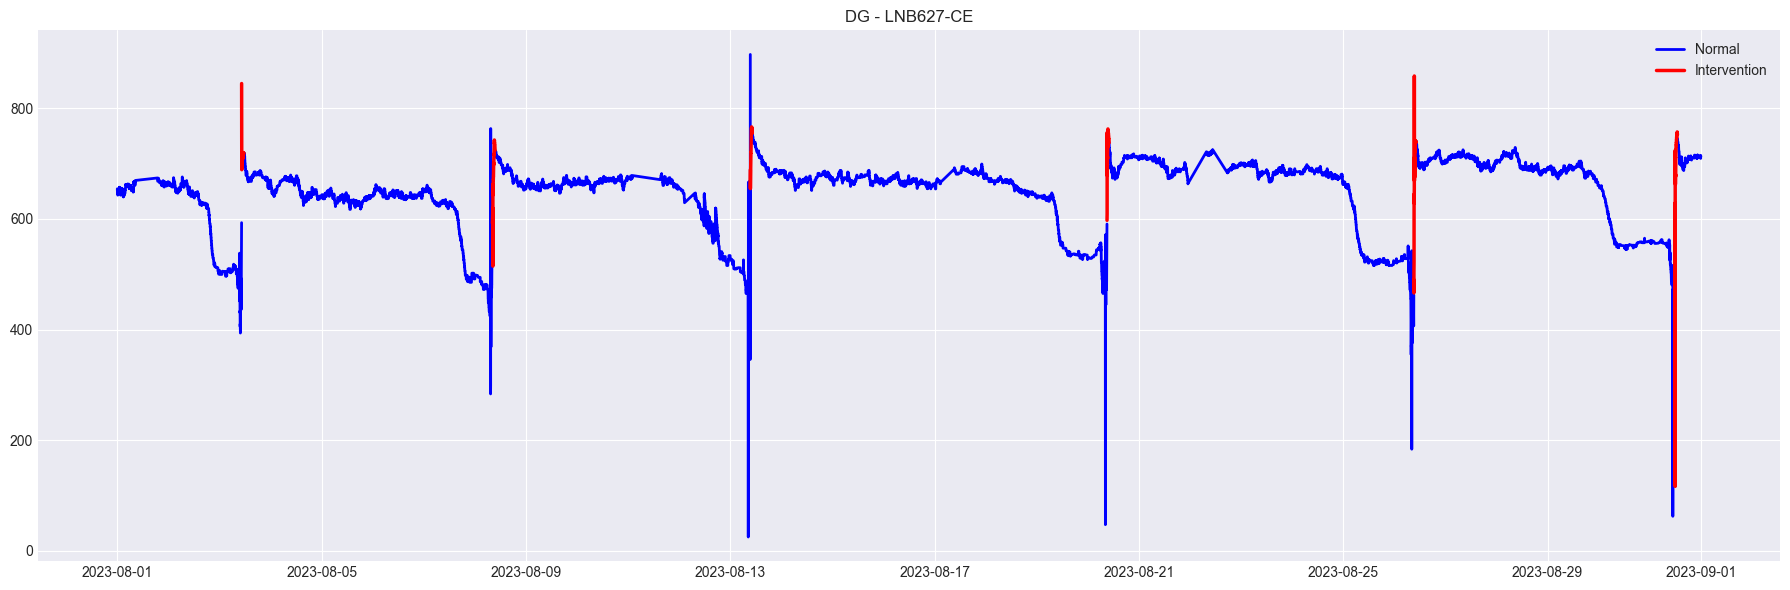

In [17]:
start_time = "2023-08-01 00:00:00"
end_time   = "2023-08-31 23:59:59"

plot_df = train_final[
    (train_final["time"] >= start_time) &
    (train_final["time"] <= end_time)
]

plot_colored_curve(plot_df, well="LNB627-CE", sensor="DG")

## 13. Advanced Feature Engineering
Generate statistical, domain-specific, and lag features required for the forecasting model.


In [18]:
def add_fft_feature(series, window=120):
    """
    Add FFT energy feature to a time series
    
    Args:
        series: Input time series
        window: Window size for FFT computation
    
    Returns:
        Series with FFT energy values
    """
    values = series.astype(float).values
    fft_energy = np.full(len(values), np.nan, dtype=np.float32)

    for i in range(window, len(values)):
        segment = values[i-window:i]
        
        # Skip if too many NaNs in the segment
        if np.isnan(segment).mean() > 0.3:
            continue
        
        segment = np.nan_to_num(segment)
        fft_vals = np.abs(np.fft.rfft(segment))
        fft_energy[i] = np.mean(fft_vals)

    return pd.Series(fft_energy, index=series.index)


def rolling_slope(series, window=360):
    """
    Calculate rolling slope using simple linear regression
    
    Args:
        series: Input time series
        window: Window size for slope calculation
    
    Returns:
        Array of rolling slopes
    """
    slopes = np.full(len(series), np.nan)
    for i in range(window, len(series)):
        y = series.iloc[i-window:i].values
        if np.isnan(y).any():
            continue
        x = np.arange(window)
        slope = np.polyfit(x, y, 1)[0]
        slopes[i] = slope
    return slopes


def engineer_features(
    df,
    well_col='well',
    time_col='time',
    fft_window=120
):
    """
    Comprehensive feature engineering for well production data
    
    Args:
        df: Input DataFrame with well data
        well_col: Column name for well identifier
        time_col: Column name for timestamp
        fft_window: Window size for FFT features
    
    Returns:
        DataFrame with engineered features
    """
    feature_list = []

    for well in df[well_col].unique():
        print(f"Processing well: {well}")
        
        # Filter and sort data for this well
        df_w = (
            df[df[well_col] == well]
            .sort_values(time_col)
            .set_index(time_col)
        )

        if len(df_w) < 200:
            print(f"    Skipping: insufficient data ({len(df_w)} rows)")
            continue

        # Start with raw sensor data
        df_feat = df_w[['CM', 'DG', 'PT', 'PL', 'DP', 'OF']].copy()
        
        # TIME-BASED FEATURES
        df_feat = _add_time_features(df_feat)
        
        # LAG FEATURES
        df_feat = _add_lag_features(df_feat)
        
        # DIFFERENCE FEATURES (rate of change)
        df_feat = _add_difference_features(df_feat)
        
        # ROLLING STATISTICS
        df_feat = _add_rolling_statistics(df_feat)
        
        # EXPONENTIAL MOVING AVERAGES (EMA)
        df_feat = _add_ema_features(df_feat)
        
        # TREND FEATURES
        df_feat = _add_trend_features(df_feat)
        
        # Z-SCORE FEATURES (standardized anomaly detection)
        df_feat = _add_zscore_features(df_feat)
        
        # FREQUENCY DOMAIN FEATURES (FFT)
        df_feat = _add_fft_features(df_feat, fft_window)
        
        # PRESSURE-DERIVED FEATURES
        df_feat = _add_pressure_features(df_feat)
        
        # SECTION 10: FLOW-DERIVED FEATURES
        df_feat = _add_flow_features(df_feat)
        
        # VALVE-DERIVED FEATURES
        df_feat = _add_valve_features(df_feat)
        
        # ADVANCED DG FEATURES
        df_feat = _add_advanced_dg_features(df_feat)
        
        # DEGRADATION FEATURES
        df_feat = _add_degradation_features(df_feat)
        
        # PRESSURE/FLOW INTERACTION FEATURES
        df_feat = _add_interaction_features(df_feat)
        
        # SECTION 15: STABILITY FEATURES
        df_feat = _add_stability_features(df_feat)
        
        # INTERVENTION FEATURES
        df_feat = _add_intervention_features(df_feat, df_w)
        
        # RECOVERY FEATURES
        df_feat = _add_recovery_features(df_feat)
        
        # PEAK AND SLOPE FEATURES
        df_feat = _add_peak_and_slope_features(df_feat, df_w)
        
        # SECTION 19: CLEANING AND FINALIZATION
        df_feat = _clean_features(df_feat, well_col, well)
        
        # Append to list
        feature_list.append(df_feat)

    # Combine all wells
    if len(feature_list) == 0:
        raise ValueError("No features generated - check your data")

    return pd.concat(feature_list).reset_index()

def _add_time_features(df_feat):
    """Add cyclical time features"""
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
    df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
    df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)
    
    return df_feat


def _add_lag_features(df_feat):
    """Add lag features for key columns"""
    for lag in [30, 60, 180, 360, 720]:
        for col in ['DG', 'PT', 'DP']:
            df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)
    return df_feat


def _add_difference_features(df_feat):
    """Add difference features (rate of change)"""
    for col in ['DG', 'PT', 'DP']:
        df_feat[f'{col}_diff_1'] = df_feat[col].diff(1)
        df_feat[f'{col}_diff_5'] = df_feat[col].diff(5)
        df_feat[f'{col}_diff_30'] = df_feat[col].diff(30)
    return df_feat


def _add_rolling_statistics(df_feat):
    """Add rolling statistics (mean, std, min, max)"""
    for col in ['DG', 'PT', 'DP']:
        for win in [20, 60, 180]:
            roll = df_feat[col].rolling(win, min_periods=5)
            df_feat[f'{col}_mean_{win}'] = roll.mean()
            df_feat[f'{col}_std_{win}'] = roll.std()
            df_feat[f'{col}_min_{win}'] = roll.min()
            df_feat[f'{col}_max_{win}'] = roll.max()
    return df_feat


def _add_ema_features(df_feat):
    """Add exponential moving averages and crossover signals"""
    for col in ['DG', 'PT', 'DP']:
        ema20 = df_feat[col].ewm(span=20, adjust=False).mean()
        ema60 = df_feat[col].ewm(span=60, adjust=False).mean()
        ema180 = df_feat[col].ewm(span=180, adjust=False).mean()
        
        df_feat[f'{col}_ema_20'] = ema20
        df_feat[f'{col}_ema_60'] = ema60
        df_feat[f'{col}_ema_180'] = ema180
        
        # EMA crossover signals
        df_feat[f'{col}_ema_gap'] = ema20 - ema60
        df_feat[f'{col}_ema_ratio'] = ema20 / (ema60 + 1e-6)
    return df_feat


def _add_trend_features(df_feat):
    """Add trend features using shifts"""
    for col in ['DG', 'PT', 'DP']:
        df_feat[f'{col}_trend_60'] = df_feat[col] - df_feat[col].shift(60)
        df_feat[f'{col}_trend_180'] = df_feat[col] - df_feat[col].shift(180)
    
    # Additional trend for DG (720)
    df_feat['DG_trend_720'] = df_feat['DG'] - df_feat['DG'].shift(720)
    
    return df_feat


def _add_zscore_features(df_feat):
    """Add Z-score features for anomaly detection"""
    for col in ['DG', 'PT', 'DP']:
        mean60 = df_feat[col].rolling(60, min_periods=5).mean()
        std60 = df_feat[col].rolling(60, min_periods=5).std()
        df_feat[f'{col}_zscore'] = (df_feat[col] - mean60) / (std60 + 1e-6)
    return df_feat


def _add_fft_features(df_feat, fft_window):
    """Add FFT energy features (frequency domain)"""
    df_feat['DG_fft_energy'] = add_fft_feature(df_feat['DG'], fft_window)
    df_feat['PT_fft_energy'] = add_fft_feature(df_feat['PT'], fft_window)
    df_feat['DP_fft_energy'] = add_fft_feature(df_feat['DP'], fft_window)
    
    # Long FFT
    df_feat['DG_fft_energy_360'] = add_fft_feature(df_feat['DG'], 360)
    
    return df_feat


def _add_pressure_features(df_feat):
    """Add pressure-derived features"""
    df_feat['PT_PL_diff'] = df_feat['PT'] - df_feat['PL']
    df_feat['DP_PT_gap'] = df_feat['DP'] - df_feat['PT']
    df_feat['pressure_ratio'] = df_feat['PT'] / np.maximum(df_feat['PL'], 1)
    df_feat['pressure_drop'] = df_feat['PT'].diff(5)
    df_feat['pressure_instability'] = (
        df_feat['PT'].rolling(60, min_periods=5).std() /
        (df_feat['PT'].rolling(60, min_periods=5).mean() + 1e-6)
    )
    return df_feat


def _add_flow_features(df_feat):
    """Add flow-derived features"""
    df_feat['flow_efficiency'] = df_feat['DG'] / np.maximum(df_feat['DP'], 1)
    df_feat['flow_per_pressure'] = df_feat['DG'] / np.maximum(df_feat['PT'], 1)
    df_feat['flow_change_60'] = df_feat['DG'] - df_feat['DG'].shift(60)
    return df_feat


def _add_valve_features(df_feat):
    """Add valve-derived features"""
    df_feat['valve_drift'] = df_feat['OF'].diff(30)
    df_feat['valve_change_rate'] = df_feat['OF'].pct_change().clip(-10, 10)
    return df_feat


def _add_advanced_dg_features(df_feat):
    """Add advanced DG features with longer windows"""
    for win in [360, 720, 1440]:
        roll = df_feat['DG'].rolling(win, min_periods=20)
        
        df_feat[f'DG_mean_{win}'] = roll.mean()
        df_feat[f'DG_std_{win}'] = roll.std()
        df_feat[f'DG_min_{win}'] = roll.min()
        df_feat[f'DG_max_{win}'] = roll.max()
        df_feat[f'DG_range_{win}'] = (
            df_feat[f'DG_max_{win}'] - df_feat[f'DG_min_{win}']
        )
    
    return df_feat


def _add_degradation_features(df_feat):
    """Add degradation features"""
    df_feat['DG_degradation_6h'] = df_feat['DG'] - df_feat['DG'].shift(360)
    df_feat['DG_degradation_12h'] = df_feat['DG'] - df_feat['DG'].shift(720)
    df_feat['DG_degradation_24h'] = df_feat['DG'] - df_feat['DG'].shift(1440)
    return df_feat


def _add_interaction_features(df_feat):
    """Add pressure/flow interaction features"""
    df_feat['DG_PT_product'] = df_feat['DG'] * df_feat['PT']
    df_feat['DG_DP_product'] = df_feat['DG'] * df_feat['DP']
    df_feat['PT_DP_ratio'] = df_feat['PT'] / (df_feat['DP'] + 1e-6)
    return df_feat


def _add_stability_features(df_feat):
    """Add stability features (coefficient of variation)"""
    df_feat['DG_cv_60'] = (
        df_feat['DG_std_60'] / (df_feat['DG_mean_60'] + 1e-6)
    )
    
    df_feat['DG_cv_180'] = (
        df_feat['DG'].rolling(180).std() /
        (df_feat['DG'].rolling(180).mean() + 1e-6)
    )
    
    df_feat['PT_cv_60'] = (
        df_feat['PT_std_60'] /
        (df_feat['PT_mean_60'] + 1e-6)
    )
    
    return df_feat


def _add_intervention_features(df_feat, df_w):
    """Add intervention-related features"""
    # Direct intervention flags
    if 'is_intervention' in df_w.columns:
        df_feat['is_intervention'] = df_w['is_intervention'].astype(np.float32)

    if 'hours_since_intervention' in df_w.columns:
        df_feat['hours_since_intervention'] = df_w['hours_since_intervention'].astype(np.float32)

    if 'hours_to_intervention' in df_w.columns:
        df_feat['hours_to_intervention'] = df_w['hours_to_intervention'].astype(np.float32)

    # Position in intervention cycle
    if ('hours_since_intervention' in df_w.columns and 
        'hours_to_intervention' in df_w.columns):
        df_feat['intervention_cycle'] = (
            df_w['hours_since_intervention'] / 
            (df_w['hours_since_intervention'] + df_w['hours_to_intervention'] + 1e-6)
        )

    # Flow degradation since last intervention
    if 'hours_since_intervention' in df_w.columns:
        df_feat['dg_decay_since_intervention'] = (
            df_feat['DG'] / (df_w['hours_since_intervention'] + 1)
        )
        
        df_feat['pt_since_intervention'] = (
            df_feat['PT'] / (df_w['hours_since_intervention'] + 1)
        )
        
        # Intervention effect trends
        df_feat['DG_after_intervention_trend'] = (
            df_feat['DG'] * np.log1p(df_w['hours_since_intervention'])
        )
        
        df_feat['PT_after_intervention_trend'] = (
            df_feat['PT'] * np.log1p(df_w['hours_since_intervention'])
        )
        
        # Log of hours since intervention
        df_feat['hours_since_intervention_log'] = np.log1p(
            df_w['hours_since_intervention']
        )
    
    return df_feat


def _add_recovery_features(df_feat):
    """Add recovery features"""
    df_feat['DG_recovery_6h'] = (
        df_feat['DG'] - df_feat['DG'].rolling(360).min()
    )
    
    df_feat['DG_recovery_24h'] = (
        df_feat['DG'] - df_feat['DG'].rolling(1440).min()
    )
    
    return df_feat


def _add_peak_and_slope_features(df_feat, df_w):
    """
    Add peak detection, loss from peak, degradation rate, 
    and rolling slope features
    """
    # 1. Rolling maximum (1440 window)
    df_feat['dg_roll_max_1440'] = df_feat['DG'].rolling(1440, min_periods=20).max()
    
    # 2. Loss from peak (peak - current value)
    df_feat['dg_loss_from_peak'] = df_feat['dg_roll_max_1440'] - df_feat['DG']
    
    # 3. Degradation rate (change over 360 periods)
    df_feat['dg_degradation_rate'] = (
        (df_feat['DG'] - df_feat['DG'].shift(360)) / 360
    )
    
    # 4. Rolling slope (using linear regression over 360 periods)
    df_feat['dg_rolling_slope_360'] = rolling_slope(df_feat['DG'], window=360)
    
    # 5. Loss since last intervention
    if 'hours_since_intervention' in df_w.columns:
        # Rolling maximum since intervention (using 1440 window as proxy)
        peak_since_intervention = df_feat['DG'].rolling(
            window=1440, min_periods=20
        ).max()
        df_feat['dg_loss_since_intervention'] = (
            peak_since_intervention - df_feat['DG']
        )
    
    return df_feat


def _clean_features(df_feat, well_col, well):
    """Clean features by handling infinities, NaNs, and outliers"""
    numeric_cols = df_feat.select_dtypes(include=np.number).columns

    # Replace infinities with NaN
    df_feat[numeric_cols] = df_feat[numeric_cols].replace([np.inf, -np.inf], np.nan)

    df_feat[numeric_cols] = df_feat[numeric_cols].ffill()

    # Fill any remaining NaNs with median
    for col in numeric_cols:
        median_val = df_feat[col].median()
        if np.isnan(median_val):
            median_val = 0
        df_feat[col] = df_feat[col].fillna(median_val)

        # Clip extreme outliers
        q001 = df_feat[col].quantile(0.001)
        q999 = df_feat[col].quantile(0.999)
        if pd.notna(q001) and pd.notna(q999):
            df_feat[col] = df_feat[col].clip(q001, q999)

    # Add well identifier
    df_feat[well_col] = well

    return df_feat


# EXECUTE FEATURE ENGINEERING

# Process training data
train_features = engineer_features(train_final)

# Process validation data
val_features = engineer_features(val_final)

Processing well: LNB627-CE
Processing well: LNB627-CE


## 14. Forecast Horizon and Target Creation
Create the forecasting target: `target(t) = DG(t + 360)`. Drop rows where this future value is unavailable.


In [19]:
def create_forecast_target(df, horizon=360):
    out_frames = []
    for well, df_w in df.groupby("well"):
        df_w = df_w.sort_values('time')
        df_w['target'] = df_w['DG'].shift(-horizon)
        df_w = df_w.dropna(subset=['target'])
        out_frames.append(df_w)
    return pd.concat(out_frames).reset_index(drop=True)

train_labeled = create_forecast_target(train_features, horizon=180)
val_labeled = create_forecast_target(val_features, horizon=180)

# Convert to datetime index
train_df = train_labeled.set_index('time')
val_df = val_labeled.set_index('time')

print("After target alignment:")
print("Train shape:", train_df.shape, "Val shape:", val_df.shape)


After target alignment:
Train shape: (344670, 153) Val shape: (124325, 153)


In [20]:
print(train_labeled["DG"].describe())

count    344670.000000
mean        649.571340
std          74.197030
min          64.806038
25%         634.859680
50%         669.431763
75%         693.229492
max         809.834850
Name: DG, dtype: float64


In [21]:
feature_cols = [

    # RAW
    'DG',
    'CM',
    'PT',
    'PL',
    'DP',
    'OF',

    # LAGS
    'DG_lag_30',
    'DG_lag_60',
    'DG_lag_180',
    'DG_lag_360',
    'DG_lag_720',

    'PT_lag_60',
    'PT_lag_180',
    'PT_lag_360',

    'DP_lag_60',
    'DP_lag_180',
    'DP_lag_360',

    # DIFFERENCES
    'DG_diff_1',
    'DG_diff_5',
    'DG_diff_30',

    'PT_diff_5',
    'PT_diff_30',

    'DP_diff_5',
    'DP_diff_30',

    # ROLLING MEAN
    'DG_mean_60',
    'DG_mean_180',
    'DG_mean_720',

    'PT_mean_60',
    'PT_mean_180',

    'DP_mean_60',
    'DP_mean_180',

    # ROLLING STD
    'DG_std_60',
    'DG_std_180',

    'PT_std_60',
    'DP_std_60',

    # EMA
    'DG_ema_60',
    'DG_ema_180',

    'PT_ema_60',
    'DP_ema_60',

    'DG_ema_gap',
    'PT_ema_gap',
    'DP_ema_gap',

    # TREND
    'DG_trend_60',
    'DG_trend_180',
    'DG_trend_720',

    'PT_trend_60',
    'PT_trend_180',

    'DP_trend_60',
    'DP_trend_180',

    # Z SCORE
    'DG_zscore',
    'PT_zscore',
    'DP_zscore',

    # FFT
    'DG_fft_energy',
    'PT_fft_energy',
    'DP_fft_energy',

    # PRESSURE
    'PT_PL_diff',
    'DP_PT_gap',
    'pressure_ratio',
    'pressure_drop',
    'pressure_instability',

    # FLOW
    'flow_efficiency',
    'flow_per_pressure',
    'flow_change_60',

    # DEGRADATION
    'dg_roll_max_1440',
    'dg_loss_from_peak',
    'dg_degradation_rate',
    'dg_rolling_slope_360',

    # VALVE
    'valve_drift',
    'valve_change_rate',

    # TIME
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',

    # INTERVENTION HISTORY ONLY
    'is_intervention',
    'hours_since_intervention',
    'dg_decay_since_intervention',
    'pt_since_intervention',
    'dg_loss_since_intervention',
    'hours_since_intervention_log',
]

def align_features(df, feature_cols):
    df = df.copy()
    for col in feature_cols:
        if col not in df.columns:
            df[col] = np.nan
    df = df.replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df.groupby("well")[feature_cols].ffill().bfill()
    
    # Final fallback
    medians = df[feature_cols].median()
    df[feature_cols] = df[feature_cols].fillna(medians)
    return df

train_df = align_features(train_df, feature_cols)
val_df = align_features(val_df, feature_cols)

# Apply RobustScaler
scaler = RobustScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

# Target Scaling
dg_idx = feature_cols.index('DG')
center_dg = scaler.center_[dg_idx]
scale_dg = scaler.scale_[dg_idx]

train_df['target_scaled'] = (train_df['target'] - center_dg) / scale_dg
val_df['target_scaled'] = (val_df['target'] - center_dg) / scale_dg

print("Scaling complete.")


Scaling complete.


In [22]:
SEQ_LEN = 360        
BATCH_SIZE = 64
SEED = 42

TRAIN_STRIDE = 30
VAL_STRIDE = 120

np.random.seed(SEED)
tf.random.set_seed(SEED)

def build_cache(df, feature_cols):
    cache = {}
    for well, df_w in df.groupby("well"):
        df_w = df_w.sort_index()
        cache[well] = {
            "X": df_w[feature_cols].values.astype(np.float32),
            "y": df_w["target_scaled"].values.astype(np.float32)
        }
    return cache

def build_index_map(df, seq_len, stride):
    indexes = []
    for well, df_w in df.groupby("well"):
        df_w = df_w.sort_index()
        n = len(df_w)
        if n < seq_len:
            continue
        for start in range(0, n - seq_len + 1, stride):
            indexes.append((well, start))
    return indexes

def forecast_generator(indexes, cache, batch_size, seq_len):
    n_features = next(iter(cache.values()))["X"].shape[1]
    while True:
        np.random.shuffle(indexes)
        for batch_start in range(0, len(indexes), batch_size):
            batch = indexes[batch_start:batch_start + batch_size]
            X_batch = np.zeros((len(batch), seq_len, n_features), dtype=np.float32)
            y_batch = np.zeros((len(batch), 1), dtype=np.float32)
            for j, (well, start_idx) in enumerate(batch):
                end_idx = start_idx + seq_len
                X_batch[j] = cache[well]["X"][start_idx:end_idx]
                y_batch[j, 0] = cache[well]["y"][end_idx - 1]
            yield X_batch, y_batch

def build_validation_data(df, feature_cols, seq_len, stride):
    X_val = []
    y_val = []
    y_val_raw = []
    for well, df_w in df.groupby("well"):
        df_w = df_w.sort_index()
        X = df_w[feature_cols].values.astype(np.float32)
        y = df_w["target_scaled"].values.astype(np.float32)
        y_raw = df_w["target"].values.astype(np.float32)
        n = len(df_w)
        if n < seq_len:
            continue
        for start in range(0, n - seq_len + 1, stride):
            end = start + seq_len
            X_val.append(X[start:end])
            y_val.append(y[end - 1])
            y_val_raw.append(y_raw[end - 1])
    return (
        np.asarray(X_val, dtype=np.float32),
        np.asarray(y_val, dtype=np.float32).reshape(-1, 1),
        np.asarray(y_val_raw, dtype=np.float32).reshape(-1, 1)
    )

train_cache = build_cache(train_df, feature_cols)
train_indexes = build_index_map(train_df, seq_len=SEQ_LEN, stride=TRAIN_STRIDE)
train_gen = forecast_generator(train_indexes, train_cache, BATCH_SIZE, SEQ_LEN)

X_val, y_val, y_val_raw = build_validation_data(val_df, feature_cols, seq_len=SEQ_LEN, stride=VAL_STRIDE)

print("Train windows:", len(train_indexes))
print("Val input shape:", X_val.shape)
print("Val target shape:", y_val.shape)
import math
steps_per_epoch =math.ceil(len(train_indexes) / BATCH_SIZE)
print("Steps per epoch:", steps_per_epoch)


Train windows: 11478
Val input shape: (1034, 360, 79)
Val target shape: (1034, 1)
Steps per epoch: 180


In [23]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_seq_len = max_seq_len
        self.d_model = d_model
        position = np.arange(max_seq_len)[:, None]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((max_seq_len, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pe = tf.constant(pe[None, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_seq_len": self.max_seq_len,
            "d_model": self.d_model,
        })
        return config


def transformer_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.10):
    x_norm = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, dropout=dropout
    )(x_norm, x_norm)
    # Add dropout on attention output
    attention_output = tf.keras.layers.Dropout(dropout)(attention_output)
    x = tf.keras.layers.Add()([x, attention_output])
    
    # FFN with pre-norm
    x_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    ff = tf.keras.layers.Dense(ff_dim, activation="gelu")(x_norm2)
    ff = tf.keras.layers.Dropout(dropout)(ff)
    ff = tf.keras.layers.Dense(x.shape[-1])(ff)
    ff = tf.keras.layers.Dropout(dropout)(ff)  # Extra dropout on output
    x = tf.keras.layers.Add()([x, ff])
    return x

In [24]:


# BUILD MODEL
def build_model(SEQ_LEN, feature_cols):
    inputs = tf.keras.Input(shape=(SEQ_LEN, len(feature_cols)))
    
    # ===== CNN LAYER =====
    x = tf.keras.layers.Conv1D(filters=32, kernel_size=5, padding="same")(inputs)  # Reduced filters
    x = tf.keras.layers.BatchNormalization()(x)  
    x = tf.keras.layers.Activation("gelu")(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.15)(x) 
    
    # ===== POSITIONAL ENCODING =====
    x = PositionalEncoding(SEQ_LEN, int(x.shape[-1]))(x)
    
    # ===== TRANSFORMER BLOCKS =====
    for _ in range(3):
        x = transformer_block(x, head_size=64, num_heads=8, ff_dim=256, dropout=0.15)
    
    # ===== ATTENTION POOLING =====
    attention_scores = tf.keras.layers.Dense(1, activation="tanh")(x)
    attention_scores = tf.keras.layers.Softmax(axis=1)(attention_scores)
    x = tf.keras.layers.Multiply()([x, attention_scores])
    x = tf.keras.layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)
    
    # ===== DENSE LAYERS=====
    x = tf.keras.layers.Dense(128, activation="gelu")(x)
    x = tf.keras.layers.Dropout(0.20)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(64, activation="gelu")(x)
    x = tf.keras.layers.Dropout(0.10)(x)
    
    # ===== OUTPUT LAYER =====
    outputs = tf.keras.layers.Dense(1, activation="linear")(x)
    
    model = tf.keras.Model(inputs, outputs)
    return model


# COMPILE MODEL
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-4,  
            weight_decay=1e-4,   
            clipnorm=1.0
        ),
        loss=tf.keras.losses.Huber(delta=1.0),  
        metrics=[
            'mae',
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        ]
    )
    return model

# CALLBACKS
def get_callbacks():
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=8,
        restore_best_weights=True
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        mode="min",
        factor=0.5,
        patience=5,
        ave_weights_only=False,
        min_lr=1e-7
    )

    csv_logger = tf.keras.callbacks.CSVLogger(
        'training_log.csv',    
        separator=',',
        append=False
    )
    
    model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_mae',
        mode='min',
        save_best_only=True,
        verbose=1
    )
    
    terminate_nan = tf.keras.callbacks.TerminateOnNaN()
    
    return [early_stop, reduce_lr, model_checkpoint, csv_logger, terminate_nan]


# TRAINING LOOP
def train_model(train_gen, X_val, y_val, SEQ_LEN, feature_cols, steps_per_epoch):
    # Build model
    model = build_model(SEQ_LEN, feature_cols)
    
    # Compile model
    model = compile_model(model)
    
    # Print model summary
    model.summary()
    
    # Get callbacks
    callbacks = get_callbacks()
    
    # Train
    history = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        validation_data=(X_val, y_val),
        epochs=40,
        callbacks=callbacks,
        verbose=1
    )
    
    return model, history

model, history = train_model(train_gen, X_val, y_val, SEQ_LEN, feature_cols, steps_per_epoch)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 360, 79)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 360, 32)   │     12,672 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 360, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 180, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 180, 32)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 180, 32)   │          0 │ dropout[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 32)   │         64 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 32)   │     67,104 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 180, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 180, 32)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 180, 256)  │      8,448 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 180, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 180, 32)   │      8,224 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 180, 32)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 180, 32)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 180, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 180, 32)   │     67,104 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 277,602 (1.06 MB)

 Trainable params: 277,282 (1.06 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.5489 - mae: 0.9130 - rmse: 1.3329
Epoch 1: val_mae improved from None to 0.79392, saving model to best_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - loss: 0.4159 - mae: 0.7505 - rmse: 1.1659 - val_loss: 0.4510 - val_mae: 0.7939 - val_rmse: 1.2439 - learning_rate: 1.0000e-04
Epoch 2/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2566 - mae: 0.5404 - rmse: 0.8985
Epoch 2: val_mae improved from 0.79392 to 0.76371, saving model to best_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - loss: 0.2548 - mae: 0.5336 - rmse: 0.9306 - val_loss: 0.4535 - val_mae: 0.7637 - val_rmse: 1.2808 - learning_rate: 1.0000e-04
Epoch 3/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2393 - mae: 0.5133 - rmse: 0.9100
Epoch 3: val_mae did not improve from 0.76371
180/180 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - loss: 0.2273 - mae: 0.4957 - rmse: 0.8883 - val_loss: 0.7469 - val_mae: 1.0648 - val_rmse: 1.7177 - learning_rate: 1.000

KeyboardInterrupt: 

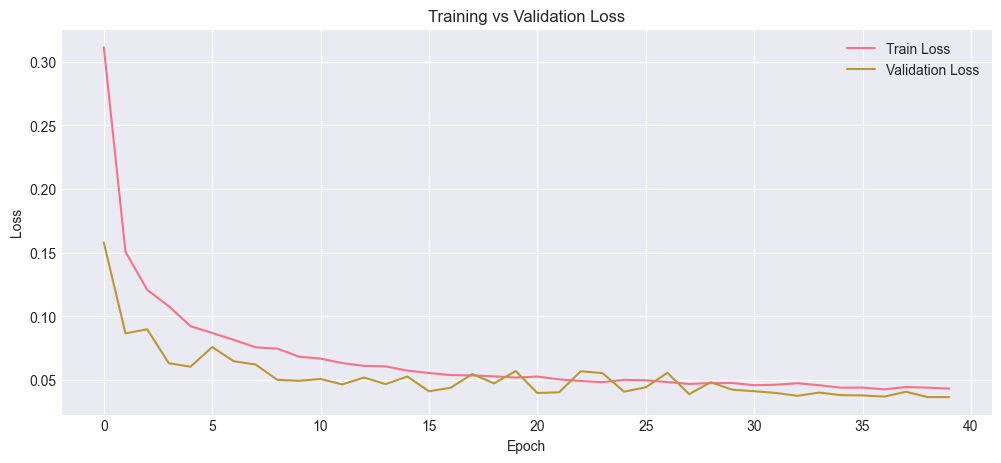

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

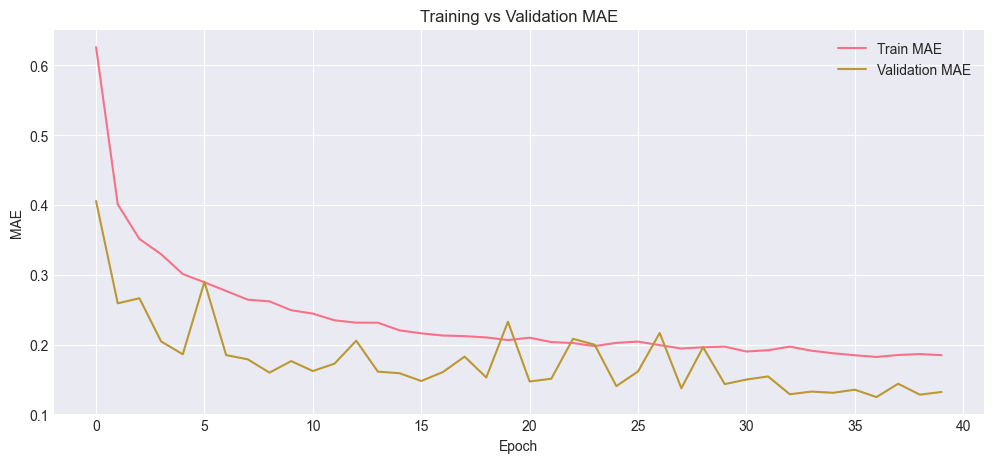

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()

plt.show()

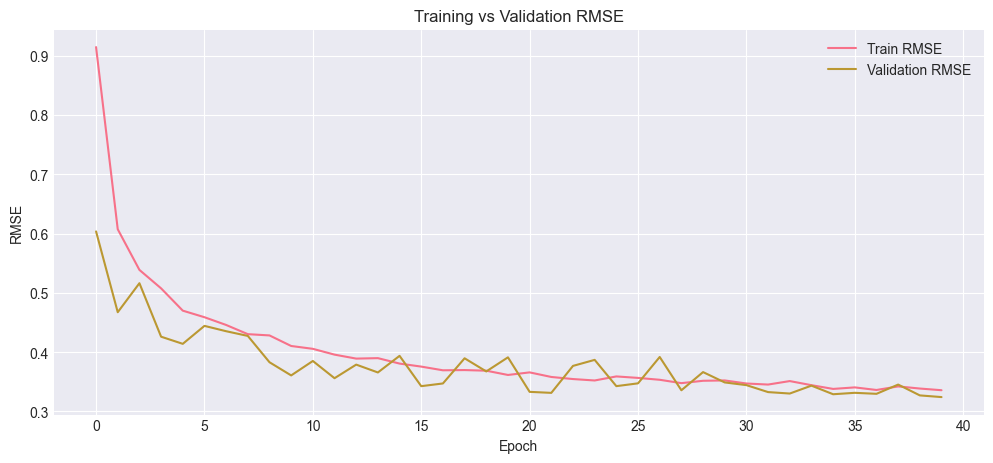

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['rmse'], label='Train RMSE')
plt.plot(history.history['val_rmse'], label='Validation RMSE')

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training vs Validation RMSE')
plt.legend()

plt.show()

In [ ]:
pred_scaled = model.predict(X_val, verbose=1)
# pred = pred_scaled * scale_dg + center_dg

# actual = y_val * scale_dg + center_dg

mae = mean_absolute_error(y_val, pred_scaled)
rmse = np.sqrt(mean_squared_error(y_val, pred_scaled))
r2 = r2_score(y_val, pred_scaled)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step
MAE : 0.1247912347316742
RMSE: 0.329763522129001
R²  : 0.8600962162017822


In [ ]:
results = pd.DataFrame({
    "Actual": y_val.flatten(),
    "Prediction": pred_scaled.flatten()
})

results["Error"] = results["Prediction"] - results["Actual"]
results["AbsoluteError"] = np.abs(results["Error"])
results["SquaredError"] = results["Error"] ** 2

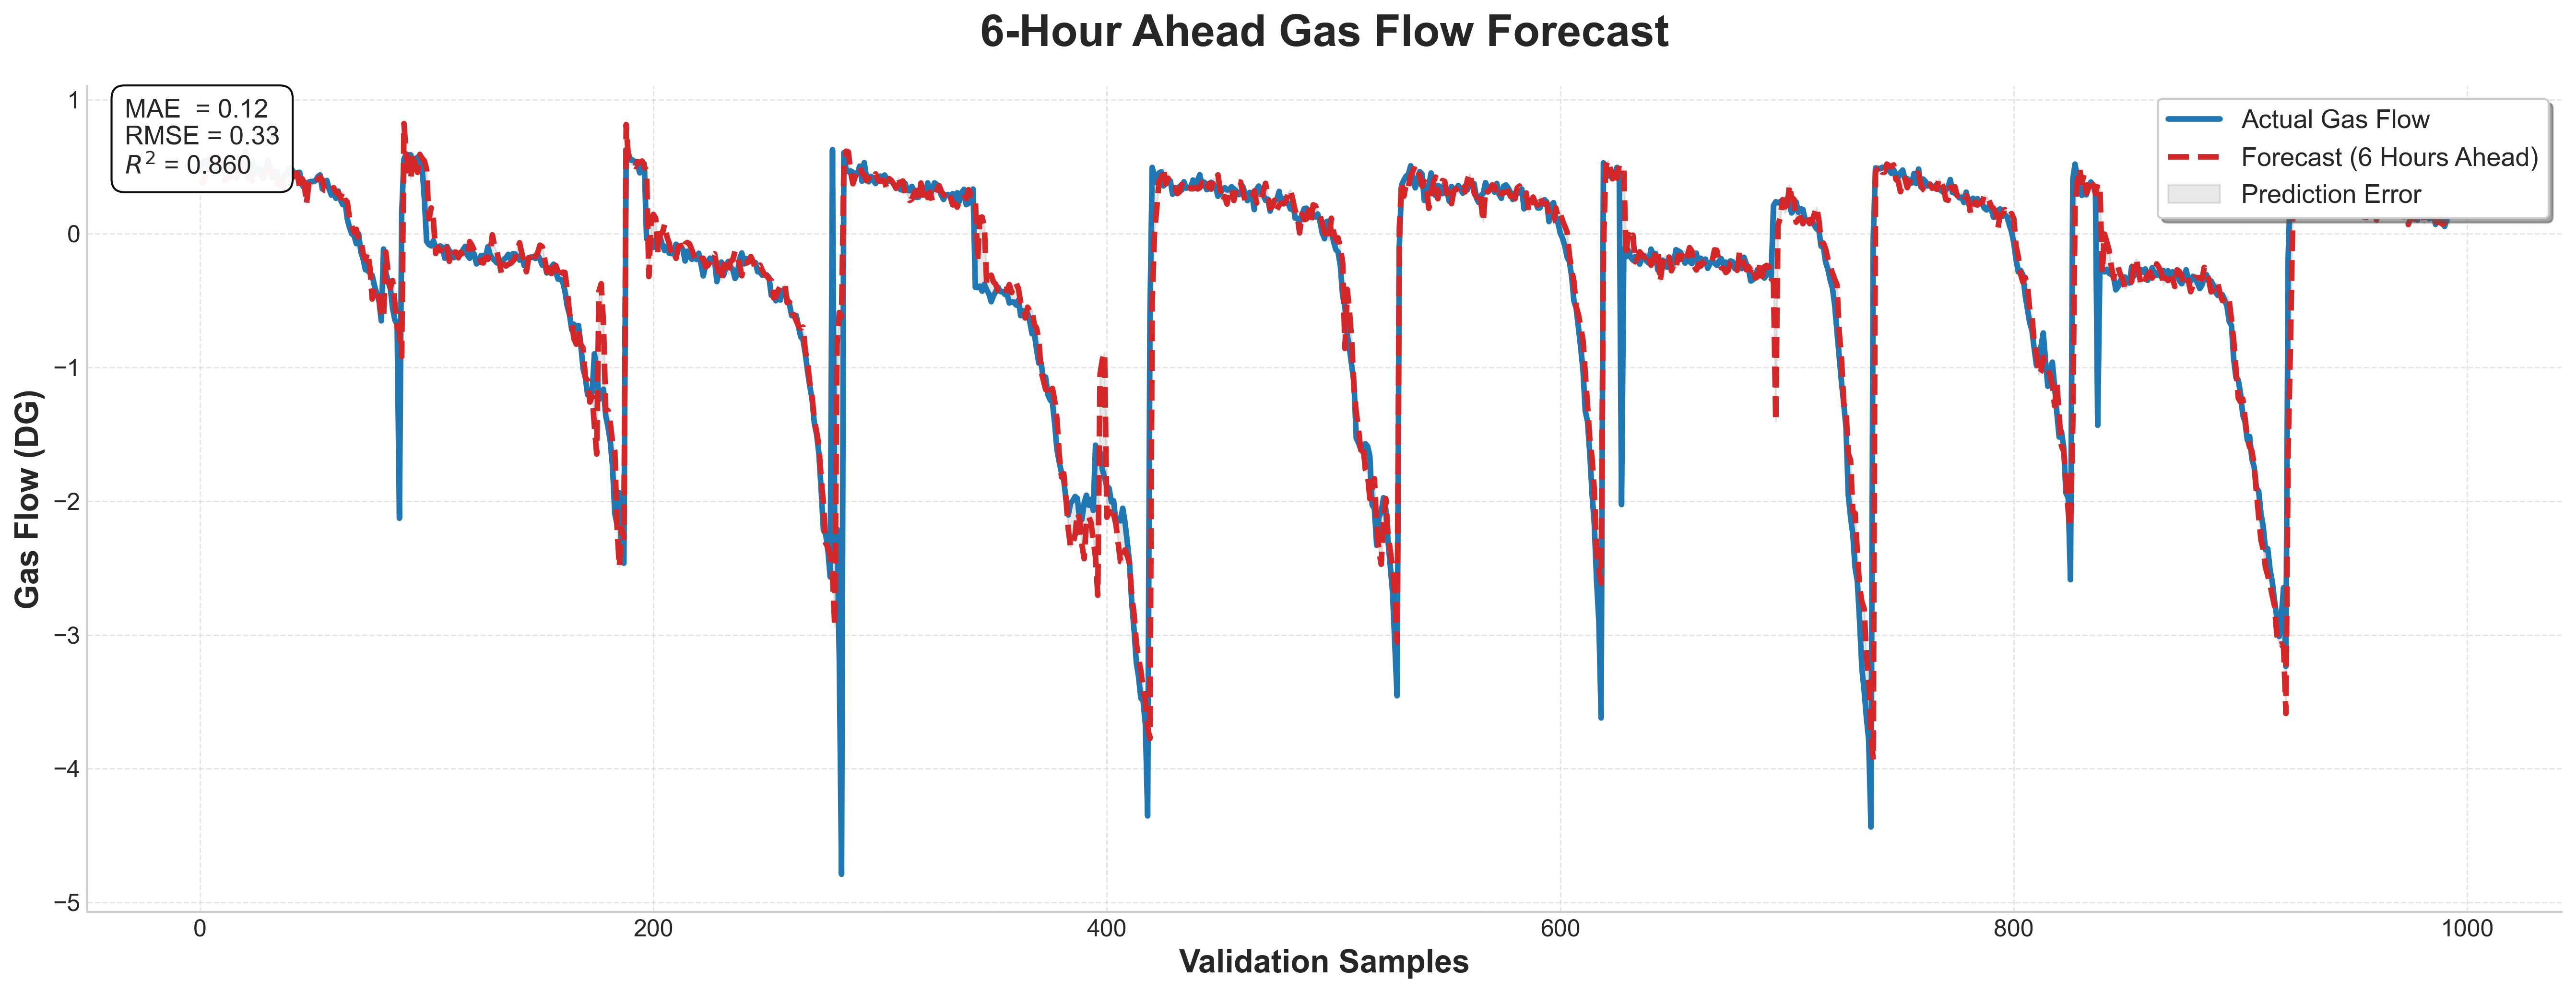

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(18, 7), dpi=300)

# Actual values
ax.plot(
    y_val.flatten(),
    color="#1f77b4",
    linewidth=2.8,
    label="Actual Gas Flow",
    zorder=3
)

# Predicted values
ax.plot(
    pred_scaled.flatten(),
    color="#d62728",
    linestyle="--",
    linewidth=2.8,
    label="Forecast (6 Hours Ahead)",
    zorder=3
)

# Prediction error area
ax.fill_between(
    np.arange(len(y_val)),
    y_val.flatten(),
    pred_scaled.flatten(),
    color="gray",
    alpha=0.18,
    label="Prediction Error"
)

# Metrics Box
metrics_text = (
    f"MAE  = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"$R^2$ = {r2:.3f}"
)

ax.text(
    0.015,
    0.985,
    metrics_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)

# Title
ax.set_title(
    "6-Hour Ahead Gas Flow Forecast",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Axis Labels
ax.set_xlabel(
    "Validation Samples",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Gas Flow (DG)",
    fontsize=16,
    fontweight="bold"
)

# Grid
ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

# Legend
ax.legend(
    fontsize=13,
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick formatting
ax.tick_params(
    axis="both",
    which="major",
    labelsize=12
)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(
    "LNB712-CE.png",
    dpi=300,
    bbox_inches="tight"
)

# plt.savefig("GasFlow_Forecast_Professional.pdf", bbox_inches="tight")

plt.show()

In [ ]:
pred = pred_scaled * scale_dg + center_dg

actual = y_val * scale_dg + center_dg

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 11.605138174328467
RMSE: 30.666828358743068
R²  : 0.8600962055016445


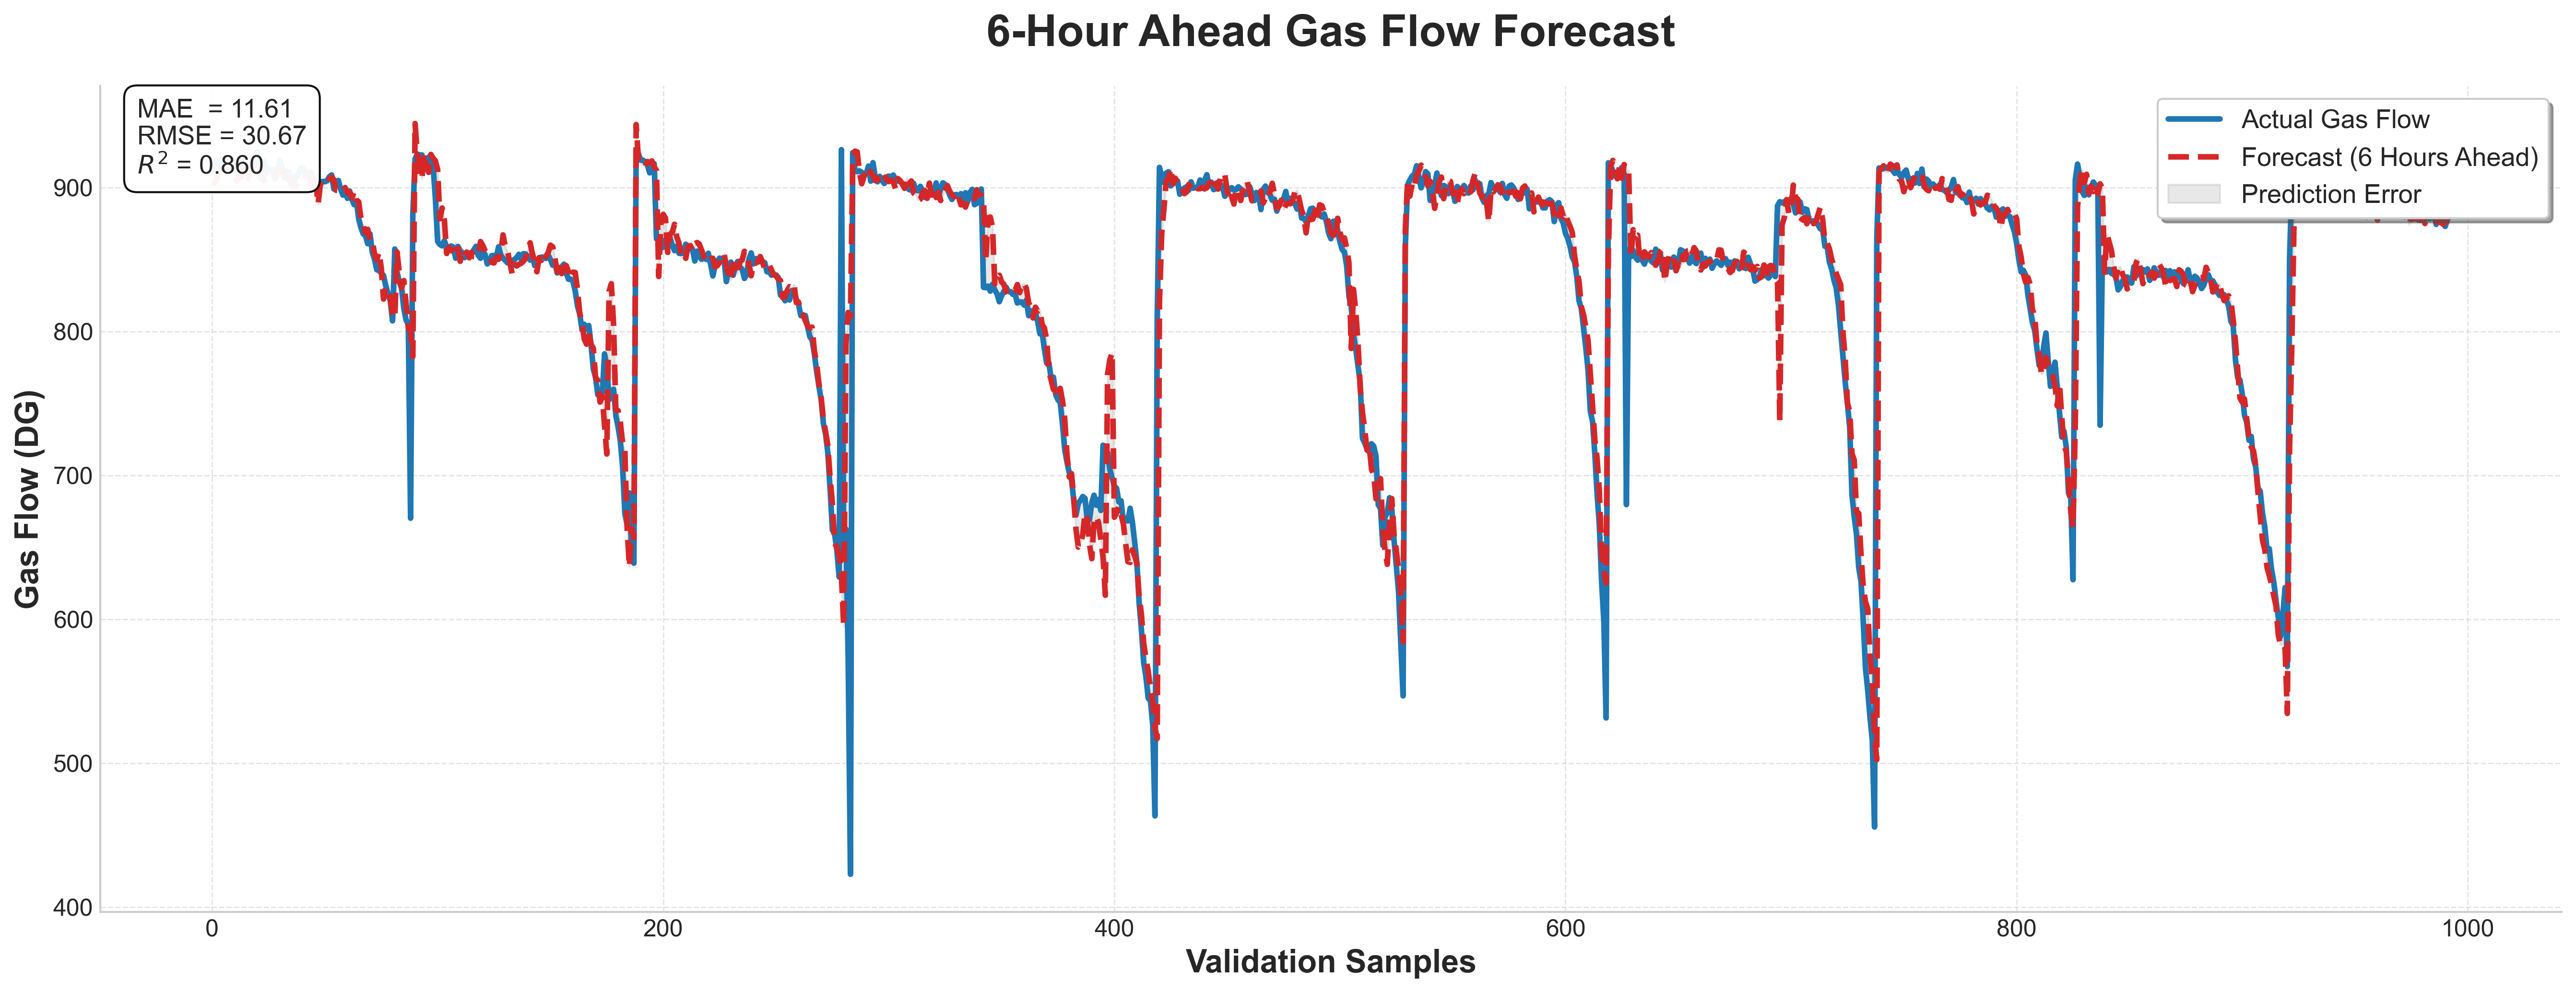

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(18, 7), dpi=300)

# Actual values
ax.plot(
    actual.flatten(),
    color="#1f77b4",
    linewidth=2.8,
    label="Actual Gas Flow",
    zorder=3
)

# Predicted values
ax.plot(
    pred.flatten(),
    color="#d62728",
    linestyle="--",
    linewidth=2.8,
    label="Forecast (6 Hours Ahead)",
    zorder=3
)

# Prediction error area
ax.fill_between(
    np.arange(len(actual)),
    actual.flatten(),
    pred.flatten(),
    color="gray",
    alpha=0.18,
    label="Prediction Error"
)

# Metrics Box
metrics_text = (
    f"MAE  = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"$R^2$ = {r2:.3f}"
)

ax.text(
    0.015,
    0.985,
    metrics_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)

# Title
ax.set_title(
    "6-Hour Ahead Gas Flow Forecast",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Axis Labels
ax.set_xlabel(
    "Validation Samples",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Gas Flow (DG)",
    fontsize=16,
    fontweight="bold"
)

# Grid
ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

# Legend
ax.legend(
    fontsize=13,
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick formatting
ax.tick_params(
    axis="both",
    which="major",
    labelsize=12
)

# Tight layout
plt.tight_layout()

plt.show()